<a href="https://colab.research.google.com/github/sayyidmahboob/SQL-Project-1/blob/main/SQL_Milestone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Football Analytics Case Study**
## A Data-Driven Approach to Team Performance

This project analyzes football player and team data to understand how performance and financial decisions impact results.

The goal is to use simple data analysis to help a football team:
- Identify top players
- Use budget efficiently
- Make better transfer decisions

## 1. Problem Statement

Football teams often spend large amounts of money on players without clearly knowing their impact on performance.

This creates problems such as:
- Overpaying players
- Poor transfer decisions
- Underperforming players staying in the team

**Key Question:**
How can a team use data to win more matches while spending money wisely?

## 2. Objective

The objective of this project is to:

- Identify top-performing players
- Evaluate value for money (performance vs salary)
- Analyze team performance
- Study player transfers
- Detect underperforming players
- Measure budget efficiency

## 3. Dataset Description

We created a simple dataset with three tables:

### Players
- Goals scored
- Assists
- Matches played
- Salary

### Teams
- Wins, losses, draws
- League position
- Budget

### Transfers
- Player movement between teams
- Transfer fees

In [ ]:
# Setup

import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

In [ ]:
# Table Creation

cursor.executescript("""
CREATE TABLE Teams (
    team_id INT PRIMARY KEY,
    team_name TEXT,
    wins INT,
    losses INT,
    draws INT,
    league_position INT,
    budget REAL
);

CREATE TABLE Players (
    player_id INT PRIMARY KEY,
    name TEXT,
    position TEXT,
    team_id INT,
    goals_scored INT,
    assists INT,
    matches_played INT,
    salary REAL
);

CREATE TABLE Transfers (
    transfer_id INT PRIMARY KEY,
    player_id INT,
    from_team_id INT,
    to_team_id INT,
    transfer_fee REAL
);
""")

In [ ]:
cursor.executescript("""
INSERT INTO Teams VALUES
(1, 'Red Warriors', 18, 5, 7, 1, 150000000),
(2, 'Blue Kings', 15, 8, 7, 3, 120000000),
(3, 'Green Giants', 12, 10, 8, 5, 90000000),
(4, 'Yellow Tigers', 10, 12, 8, 7, 70000000),
(5, 'Black Panthers', 8, 14, 8, 9, 50000000);

INSERT INTO Players VALUES
(1, 'Arjun Mehta', 'Forward', 1, 22, 5, 25, 20000000),
(2, 'Ravi Sharma', 'Midfielder', 1, 10, 12, 26, 15000000),
(3, 'John Dsouza', 'Forward', 2, 18, 6, 24, 18000000),
(4, 'Imran Khan', 'Forward', 2, 5, 3, 20, 12000000),
(5, 'David Roy', 'Midfielder', 3, 8, 10, 25, 10000000),
(6, 'Chris Paul', 'Forward', 3, 15, 4, 23, 11000000),
(7, 'Ali Hassan', 'Defender', 4, 2, 2, 22, 8000000),
(8, 'Suresh Raina', 'Forward', 4, 3, 1, 21, 9000000),
(9, 'Leo Varun', 'Forward', 5, 1, 0, 18, 7000000),
(10, 'Mark Wood', 'Midfielder', 5, 4, 5, 22, 6000000);

INSERT INTO Transfers VALUES
(1, 3, 1, 2, 25000000),
(2, 6, 2, 3, 15000000),
(3, 8, 3, 4, 8000000),
(4, 10, 4, 5, 5000000);
""")

## 4. Analysis
We now run SQL queries to answer key business questions.

In [ ]:
# TOP PERFORMER

query = """
SELECT p.name, t.team_name, p.goals_scored
FROM Players p
JOIN Teams t ON p.team_id = t.team_id
ORDER BY p.goals_scored DESC
LIMIT 5;
"""
pd.read_sql_query(query, conn)

,name,team_name,goals_scored
0,Arjun Mehta,Red Warriors,22
1,John Dsouza,Blue Kings,18
2,Chris Paul,Green Giants,15
3,Ravi Sharma,Red Warriors,10
4,David Roy,Green Giants,8


In [ ]:
# VALUE FOR MONEY

query = """
SELECT p.name, t.team_name, p.goals_scored, p.salary,
(p.goals_scored / p.salary) AS value_for_money
FROM Players p
JOIN Teams t ON p.team_id = t.team_id
ORDER BY value_for_money DESC
LIMIT 3;
"""
pd.read_sql_query(query, conn)

,name,team_name,goals_scored,salary,value_for_money
0,Chris Paul,Green Giants,15,11000000.0,0.000001
1,Arjun Mehta,Red Warriors,22,20000000.0,0.000001
2,John Dsouza,Blue Kings,18,18000000.0,0.000001


In [ ]:
# TEAM PERFORMANCE

query = """
SELECT t.team_name, t.wins, t.losses, t.draws,
SUM(p.goals_scored) AS total_goals
FROM Teams t
LEFT JOIN Players p ON t.team_id = p.team_id
GROUP BY t.team_name
ORDER BY wins Desc
LIMIT 2;
"""
pd.read_sql_query(query, conn)

,team_name,wins,losses,draws,total_goals
0,Red Warriors,18,5,7,32
1,Blue Kings,15,8,7,23


In [ ]:
# UNDER PERFORMANCE

query = """
SELECT p.name, t.team_name, p.matches_played, p.goals_scored
FROM Players p
JOIN Teams t ON p.team_id = t.team_id
WHERE p.matches_played > 10 AND p.goals_scored < 3;
"""
pd.read_sql_query(query, conn)

,name,team_name,matches_played,goals_scored
0,Ali Hassan,Yellow Tigers,22,2
1,Leo Varun,Black Panthers,18,1


## 5. Key Insights

- A few players contribute most of the goals
- Some players provide better performance relative to salary
- Some teams perform well even with lower budgets
- Certain players are underperforming despite playing many matches

## 6. Conclusion

This analysis shows that success in football is not only about spending more money.

Teams can improve performance by:
- Choosing efficient players
- Identifying underperformers early
- Using budget wisely

Data-driven decision making can help teams achieve better results with fewer resources.

## 7. Dashboard

To better understand the insights, we visualize key metrics using charts.

These visualizations help quickly identify:
- Top-performing players
- Budget efficiency of teams
- Value for money players

In [ ]:
# Import required libraries for database handling and visualization

import sqlite3          # To create and query the database
import pandas as pd     # To handle tabular data
import matplotlib.pyplot as plt  # To create charts

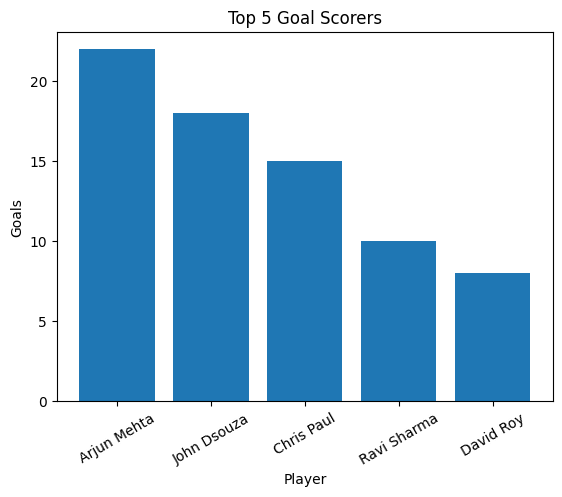

In [ ]:
# Purpose: Compare players based on total goals scored to identify top performers

query = """
SELECT name, goals_scored
FROM Players
ORDER BY goals_scored DESC
LIMIT 5;
"""

df = pd.read_sql_query(query, conn)

plt.figure()
plt.bar(df['name'], df['goals_scored'])

plt.title("Top 5 Goal Scorers")
plt.xlabel("Player")
plt.ylabel("Goals")
plt.xticks(rotation=30)

plt.show()

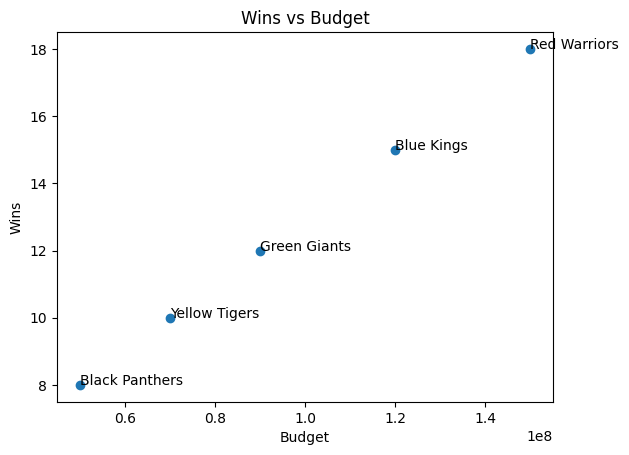

In [ ]:
# Purpose: Analyze how efficiently teams convert budget into wins (budget vs performance)

query = """
SELECT team_name, wins, budget
FROM Teams;
"""

df = pd.read_sql_query(query, conn)

plt.figure()
plt.scatter(df['budget'], df['wins'])

plt.title("Wins vs Budget")
plt.xlabel("Budget")
plt.ylabel("Wins")

for i, txt in enumerate(df['team_name']):
    plt.annotate(txt, (df['budget'][i], df['wins'][i]))

plt.show()

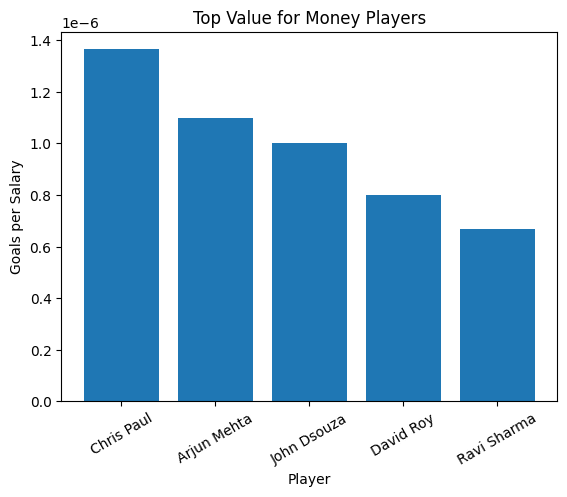

In [ ]:
# Purpose: Identify players who deliver the highest performance relative to their salary

query = """
SELECT name, (goals_scored * 1.0 / salary) AS value
FROM Players
ORDER BY value DESC
LIMIT 5;
"""

df = pd.read_sql_query(query, conn)

plt.figure()
plt.bar(df['name'], df['value'])

plt.title("Top Value for Money Players")
plt.xlabel("Player")
plt.ylabel("Goals per Salary")
plt.xticks(rotation=30)

plt.show()

## 8. Recommendations

Based on the analysis, the following actions are recommended for the team:

### 1. Retain High-Performing Players
Players with consistently high goal contributions should be prioritized for retention, as they directly impact match outcomes.

### 2. Invest in High Value-for-Money Players
Players who deliver strong performance relative to their salary should be targeted in future recruitment strategies.

### 3. Reevaluate Underperforming Players
Players with low output despite high match participation should be reviewed for:
- Role changes
- Training improvements
- Possible transfers

### 4. Optimize Budget Allocation
Instead of increasing total spending, focus on improving efficiency:
- Allocate budget toward high-impact players
- Avoid overpaying low-performing players

### 5. Improve Transfer Strategy
Transfers should be evaluated based on performance impact rather than just reputation or past performance.